In [1]:
import time
import os
import gc
import math
import cv2
import numpy as np
import pandas as pd
import pyautogui as pa
import shutil
import re  # regex
from PIL import Image, ImageDraw
import random
from scipy.stats import sem, ttest_ind, norm, ttest_ind_from_stats
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import imageio
from sklearn.cluster import KMeans

from lib.analysis.trace_metrics import TraceMetrics
from lib.analysis.false_discovery_control import false_discovery_control
from lib.auto_GUI.auto_PhotoZ import AutoPhotoZ
from lib.analysis.laminar_dist import *
from lib.analysis.align import ImageAlign
from lib.file.ROI_writer import ROIFileWriter
from lib.analysis.barrel_roi import Barrel_ROI_Creator
from lib.analysis.cell_roi import RandomROISample, OverlapCounterROI
from lib.analysis.baseline_correction import BaselineCorrection

# 2-way ANOVA for medial and lateral PPR vs IPI
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from lib.utilities import *
from lib.file.TIF import *

from ZDA_Adventure.utility import ROIFileReader




In [2]:
# Load data, not from Drive for Desktop since PhotoZ complains about loading zda from Drive
data_dir = "C:/Users/jjudge3/Desktop/Data/slow_NBQX/"
barrels_df = data_dir + 'export_summary_barrels.csv'
px_df = data_dir + 'export_summary_single_px.csv'
direct_df = data_dir + 'export_summary_direct_stim.csv'
camera_program = 4
um_per_px = 6.0 #um
output_fig_dir = 'P:/John/pv-ppr-paper/input/'

# load the CSVs
barrels_df = pd.read_csv(barrels_df)
px_df = pd.read_csv(px_df)
direct_df = pd.read_csv(direct_df)
# add column for Coronal/Sagittal
barrels_df['Section'] = 'Coronal'
px_df['Section'] = 'Coronal'
direct_df['Section'] = 'Coronal'
barrels_df

# choice barrels or single px df
dfs = [barrels_df] #, px_df]

In [3]:
def read_array_file(filename): 
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=None,
                                 names=['Index',  'Values'])
    return np.array(data_arr['Values']).reshape((80, 80))

def read_dat_trace_file(filename):
    data_arr = pd.read_csv(filename,
                                 sep='\t',
                                 header=0)  # change me to traces?
    data_arr = data_arr.apply(pd.to_numeric, errors='coerce')
    return data_arr

In [4]:
# load catalog
catalog = data_dir + "meta_catalog.csv"
catalog_df = pd.read_csv(catalog)
catalog_df

,Date,Slice,Location,Recording,time,NBQX_conc,infusion_time
0,2/6/2026,1,2,3,1:00,0.00,NaN
1,2/6/2026,1,2,4,1:03,0.00,NaN
2,2/6/2026,1,2,5,1:20,0.83,1:04
3,2/6/2026,1,2,6,1:23,0.83,1:04
4,2/6/2026,1,2,7,1:27,0.83,1:04
...,...,...,...,...,...,...,...
104,2/12/2026,1,1,33,5:25,10.00,5:04
105,2/12/2026,1,1,34,5:28,10.00,5:04
106,2/12/2026,1,1,35,5:31,10.00,5:04
107,2/12/2026,1,1,36,5:34,10.00,5:04


In [5]:

# merge catalog info into the barrels_df and px_df
for df in dfs + [direct_df]:
    df['time'] = ''
    df['NBQX_conc'] = np.nan
    # infusion time is time
    df['infusion_time'] = ''
    for index, row in df.iterrows():
        # look up the corresponding catalog entry and add the time, NBQX_conc, and infustion_time to the df
        date = row['Date']
        slic = row['Slice']
        loc = row['Location']
        rec = row['Recording']
        if '-' in date:
            date = date.replace('-', '/')
        if len(date.split('/')[2]) == 2:
            date = date[:-2] + '20' + date[-2:]
        catalog_entry = catalog_df[(catalog_df['Date'] == date) &
                                   (catalog_df['Slice'] == slic) &
                                   (catalog_df['Location'] == loc) &
                                   (catalog_df['Recording'] == rec)]
        if len(catalog_entry) == 0:
            print(f"No catalog entry found for {date}, {slic}, {loc}, {rec}")
            print("only options:", catalog_df['Date'].unique())
            continue
        elif len(catalog_entry) > 1:
            print(f"Multiple catalog entries found for {date}, {slic}, {loc}, {rec}")
            continue
        else:
            catalog_entry = catalog_entry.iloc[0]
            df.at[index, 'time'] = catalog_entry['time']
            df.at[index, 'NBQX_conc'] = catalog_entry['NBQX_conc']
            df.at[index, 'infusion_time'] = catalog_entry['infusion_time']
df

,ROI,amp,latency,stim_time,halfwidth,X_Center,Y_Center,ROI_Set,Date,Slice,Location,Recording,trace,amp_array,latency_array,Section,time,NBQX_conc,infusion_time
0,1,0.002259,49.459269,49.633276,5.149320,56,43,1_2_direct_stim,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,Coronal,1:00,0.0,NaN
1,2,0.002027,50.333326,49.633276,6.350893,53,41,1_2_direct_stim,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,Coronal,1:00,0.0,NaN
2,3,0.001932,50.089190,49.633276,5.579175,53,44,1_2_direct_stim,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,Coronal,1:00,0.0,NaN
3,4,0.002042,49.724220,49.633276,6.048040,57,40,1_2_direct_stim,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,Coronal,1:00,0.0,NaN
4,1,0.001825,49.886824,49.633276,5.823422,58,48,1_2_indirect_stim,2/6/2026,1,2,3,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-06-...,Coronal,1:00,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,5,0.001640,47.076970,49.606834,27.127747,49,34,1_1_indirect_stim,2/12/2026,1,1,37,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,Coronal,5:38,10.0,5:04
1639,6,0.001501,47.000000,49.606834,3.249226,54,36,1_1_indirect_stim,2/12/2026,1,1,37,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,Coronal,5:38,10.0,5:04
1640,7,0.002799,47.619442,49.606834,26.024932,43,38,1_1_indirect_stim,2/12/2026,1,1,37,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,Coronal,5:38,10.0,5:04
1641,8,0.001456,47.000000,49.606834,27.763350,54,45,1_1_indirect_stim,2/12/2026,1,1,37,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,C:/Users/jjudge3/Desktop/Data/slow_NBQX/02-12-...,Coronal,5:38,10.0,5:04


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

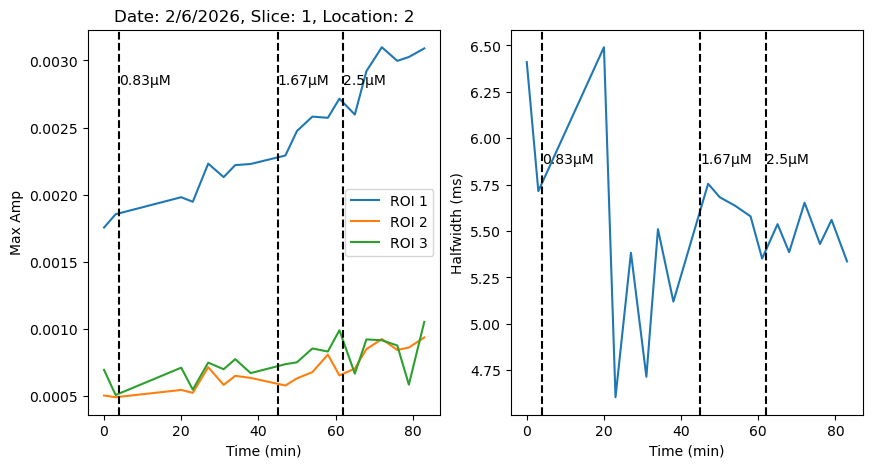

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

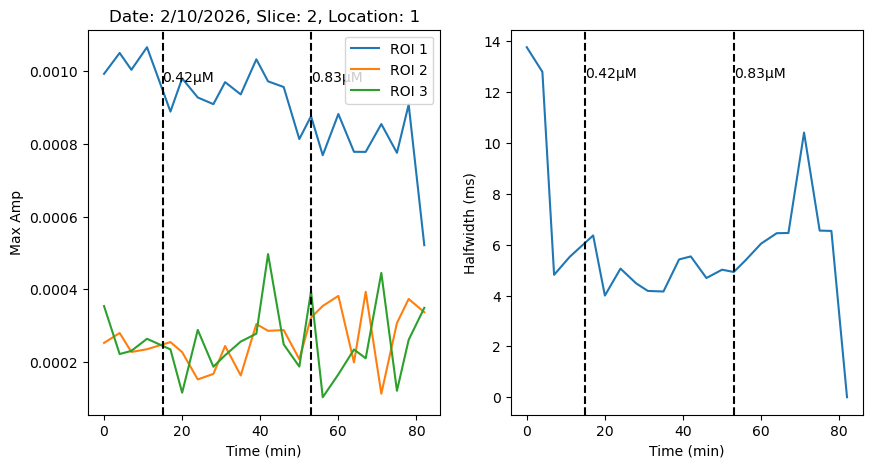

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

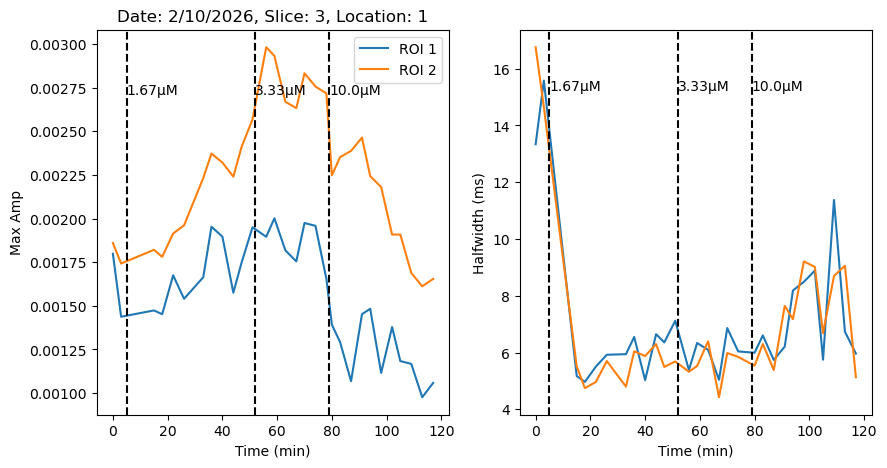

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\832916679.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

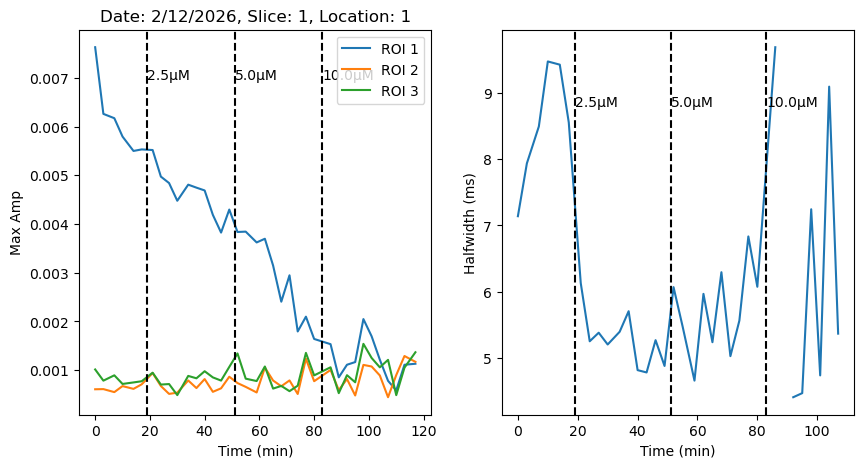

In [6]:
# plot the trace for each ROI 
for df in dfs:
    for date in df['Date'].unique():
        date_df = df[df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():

                plt.subplots(1, 2, figsize=(10, 5))
                location_df = slice_df[slice_df['Location'] == location]
                for roi in location_df['ROI'].unique():
                    roi_df = location_df[location_df['ROI'] == roi]
                    # ROI Set value
                    roi_set = roi_df['ROI_Set'].values[0]

                    times = np.array(roi_df['time'].values)
                    # convert times to time datatype to allow subtraction
                    times = pd.to_datetime(times)
                    init_time = times[0]
                    times = times - init_time  # convert to minutes relative to start of recording
                    times = times.total_seconds() / 60  # convert to minutes

                    # in subplot 1, plot the max_amp vs time
                    # each date, slic, location, recording is a different line in meta_catalog, where time can be looked up

                    plt.subplot(1, 2, 1)
                    plt.plot(times, roi_df['amp'], label=f"ROI {roi}")
                    plt.xlabel('Time (min)')
                    plt.ylabel('Max Amp')
                    plt.title(f"Date: {date}, Slice: {slic}, Location: {location}")
                    
                    # filter halfwidths > 20
                    roi_df[roi_df['halfwidth'] > 20] = np.nan
                    # stricter halfwidth filter for low-amplitude (late / high NBQX) responses
                    roi_df[(roi_df['NBQX_conc'] > 2) & (roi_df['halfwidth'] > 15)] = np.nan
                    # in subplot 2, plot halfwidth vs time
                    if roi == 1 or np.mean(roi_df['amp']) > 0.001:  # only plot halfwidth for ROI 1 or if mean amp is above threshold
                        plt.subplot(1, 2, 2)
                        plt.plot(times, roi_df['halfwidth'])
                        plt.xlabel('Time (min)')
                        plt.ylabel('Halfwidth (ms)')

                # nbqx times table to mark when each new concentration of NBQX was infused
                nbqx_times = roi_df[['NBQX_conc', 'infusion_time']].drop_duplicates()
                nbqx_conc = nbqx_times['NBQX_conc'].values
                nbqx_times = nbqx_times['infusion_time'].values
                nbqx_times = pd.to_datetime(np.array(nbqx_times))
                nbqx_times -= init_time
                nbqx_times = nbqx_times.total_seconds() / 60  # convert to minutes
                
                # mark nbqx infusion times on the plots
                for i in range(len(nbqx_times)):
                    # as vertical lines with text indicating the concentration
                    for j in range(1, 3):
                        plt.subplot(1, 2, j)
                        plt.axvline(x=nbqx_times[i], color='black', linestyle='--')
                        plt.text(nbqx_times[i], plt.ylim()[1]*0.9, f"{nbqx_conc[i]}μM", 
                                color='black', va='top', ha='left')
                plt.subplot(1, 2, 1)
                plt.legend()
                
                plt.show()
                    

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

76 247
0 76
1 247


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

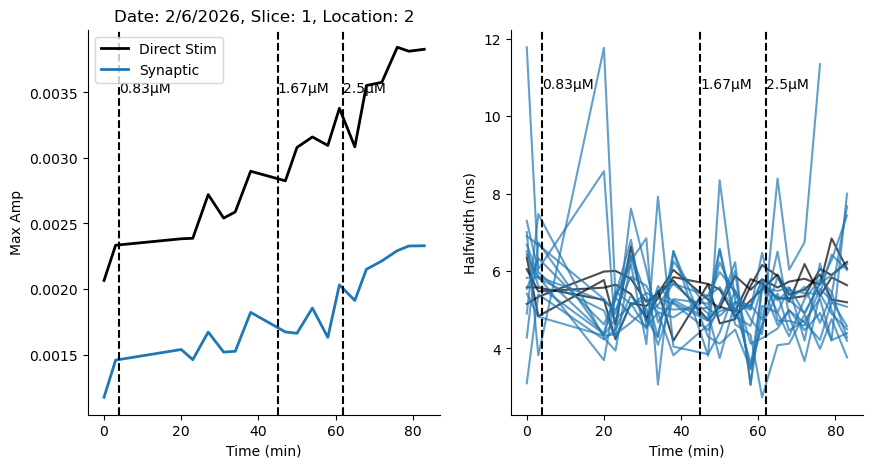

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

92 207
0 92
1 207


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

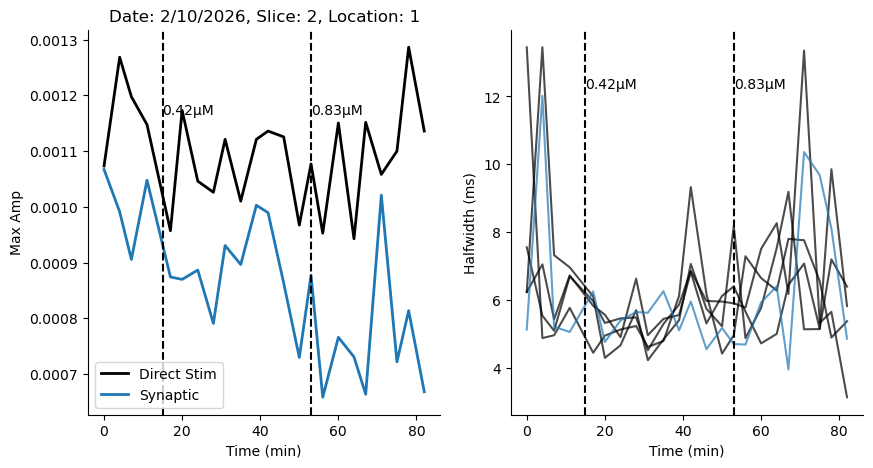

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

210 330
0 210
1 330


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[(roi_df['NBQX_conc'] > 2) & (roi_df['halfwidth'] > 15)] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:52: MatplotlibDeprecationWarning: Adding an axes using the same a

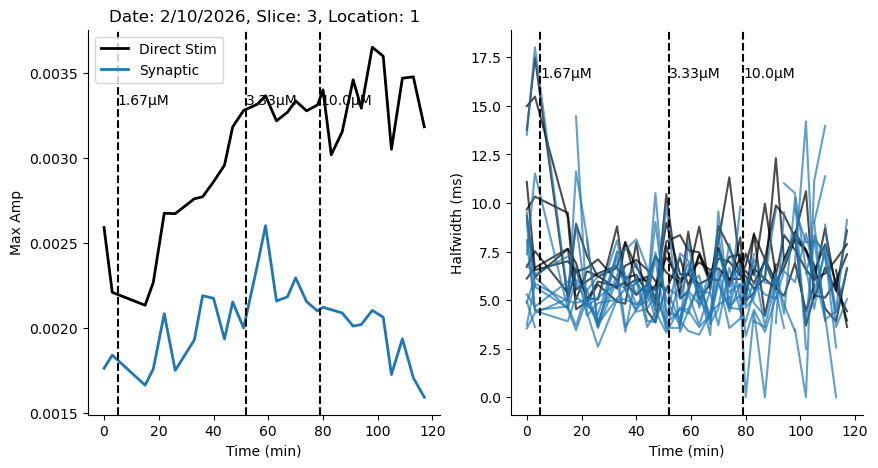

C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roi_df[roi_df['halfwidth'] > 20] = np.nan
c:\Users\jjudge3\AppData\Local\anaconda3\envs\TSM-to-ZDA\lib\site-packages\pandas\core\indexing.py:1720: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

148 333
0 148
1 333


C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:52: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 2)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)
C:\Users\jjudge3\AppData\Local\Temp\ipykernel_13664\349296491.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

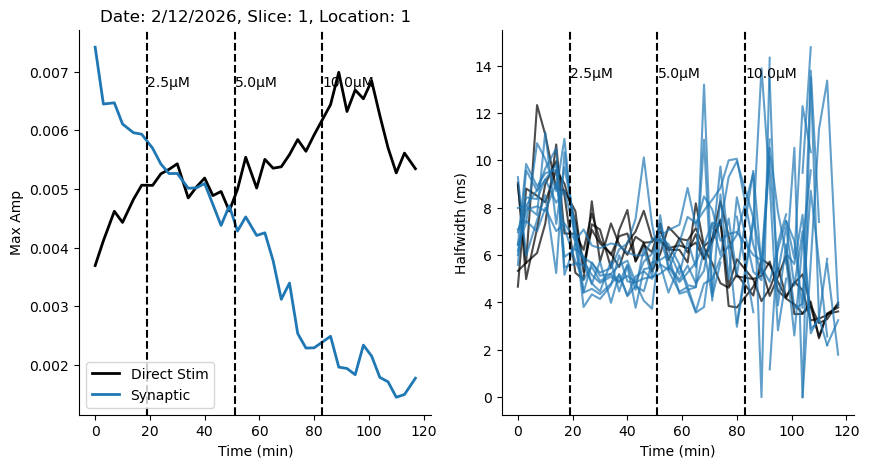

In [7]:
# direct_df 
average_trace_of_direct = True

for df in [direct_df]:
    for date in df['Date'].unique():
        date_df = df[df['Date'] == date]
        for slic in date_df['Slice'].unique():
            slice_df = date_df[date_df['Slice'] == slic]
            for location in slice_df['Location'].unique():

                plt.subplots(1, 2, figsize=(10, 5))
                location_df = slice_df[slice_df['Location'] == location]

                # divide into direct and indirect, based on if "indirect" is in the ROI_Set column
                x_indirect_df = location_df[location_df['ROI_Set'].str.contains("indirect", case=False)]
                x_direct_df = location_df[~location_df['ROI_Set'].str.contains("indirect", case=False)]
                
                print(len(x_direct_df), len(x_indirect_df))
                dir_color = ['black', 'tab:blue', ]
                for i_dir, dir_df in enumerate([x_direct_df, x_indirect_df]):
                    print(i_dir, len(dir_df))
                    avg_trace = []
                    for roi in dir_df['ROI'].unique():
                        roi_df = dir_df[dir_df['ROI'] == roi]
                        # ROI Set value
                        roi_set = roi_df['ROI_Set'].values[0]

                        times = np.array(roi_df['time'].values)
                        # convert times to time datatype to allow subtraction
                        times = pd.to_datetime(times)
                        init_time = times[0]
                        times = times - init_time  # convert to minutes relative to start of recording
                        times = times.total_seconds() / 60  # convert to minutes

                        # in subplot 1, plot the max_amp vs time
                        # each date, slic, location, recording is a different line in meta_catalog, where time can be looked up

                        plt.subplot(1, 2, 1)
                        if not average_trace_of_direct:
                            plt.plot(times, roi_df['amp'], label="Direct Stim" if i_dir == 0 else "Synaptic", color=dir_color[i_dir], alpha=0.7)

                        plt.xlabel('Time (min)')
                        plt.ylabel('Max Amp')
                        plt.title(f"Date: {date}, Slice: {slic}, Location: {location}")
                        
                        # filter halfwidths > 20
                        roi_df[roi_df['halfwidth'] > 20] = np.nan
                        # stricter halfwidth filter for low-amplitude (late / high NBQX) responses
                        roi_df[(roi_df['NBQX_conc'] > 2) & (roi_df['halfwidth'] > 15)] = np.nan
                        # in subplot 2, plot halfwidth vs time
                        if roi == 1 or np.mean(roi_df['amp']) > 0.001:  # only plot halfwidth for ROI 1 or if mean amp is above threshold
                            plt.subplot(1, 2, 2)
                            plt.plot(times, roi_df['halfwidth'], color=dir_color[i_dir], alpha=0.7)
                            plt.xlabel('Time (min)')
                            plt.ylabel('Halfwidth (ms)')
                    if average_trace_of_direct:
                        avg_trace = dir_df.groupby('time')['amp'].mean().reset_index()
                        plt.subplot(1, 2, 1)
                        plt.plot(times, avg_trace['amp'], label="Direct Stim" if i_dir == 0 else "Synaptic", color=dir_color[i_dir], linewidth=2)

                # nbqx times table to mark when each new concentration of NBQX was infused
                nbqx_times = roi_df[['NBQX_conc', 'infusion_time']].drop_duplicates()
                nbqx_conc = nbqx_times['NBQX_conc'].values
                nbqx_times = nbqx_times['infusion_time'].values
                nbqx_times = pd.to_datetime(np.array(nbqx_times))
                nbqx_times -= init_time
                nbqx_times = nbqx_times.total_seconds() / 60  # convert to minutes
                
                # mark nbqx infusion times on the plots
                for i in range(len(nbqx_times)):
                    # as vertical lines with text indicating the concentration
                    for j in range(1, 3):
                        plt.subplot(1, 2, j)
                        plt.axvline(x=nbqx_times[i], color='black', linestyle='--')
                        plt.text(nbqx_times[i], plt.ylim()[1]*0.9, f"{nbqx_conc[i]}μM", 
                                color='black', va='top', ha='left')
                plt.subplot(1, 2, 1)
                # only keep first and last handle in legend
                handles, labels = plt.gca().get_legend_handles_labels()
                if len(handles) > 2:
                    handles = [handles[0], handles[-1]]
                    labels = [labels[0], labels[-1]]
                plt.legend(handles, labels)

                # remove top and right spines
                plt.subplot(1, 2, 1)
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                plt.subplot(1, 2, 2)
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                plt.show()
                    